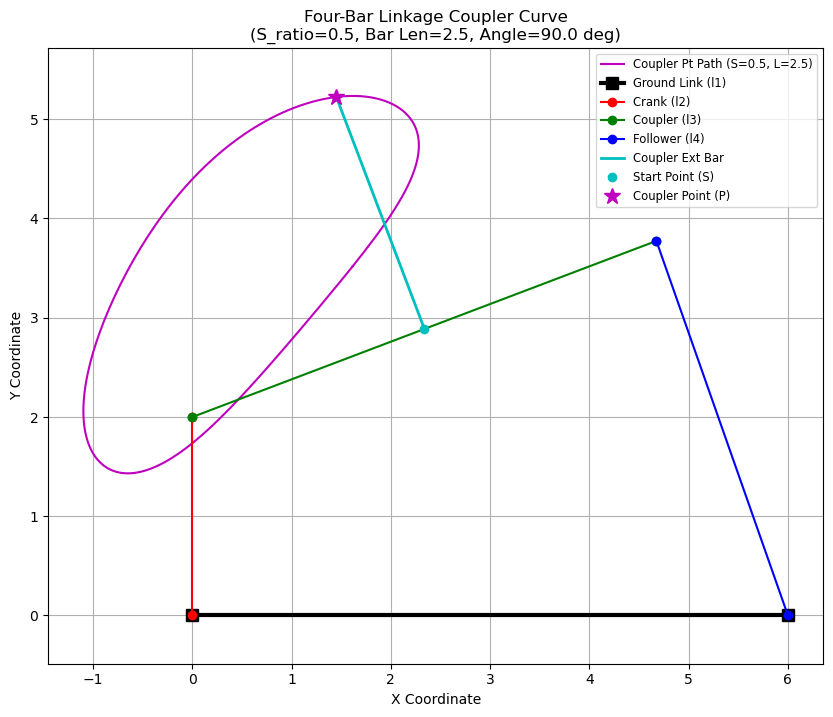


Testing Edge Cases (using default bar parameters):
Non-assemblable linkage (l3=1.0): Px=1.4792155477482578, Py=2.994015683493818 (Expect NaN)
Near singularity (l1=l2, theta2=0): Px=nan, Py=nan


In [4]:
import numpy as np
import matplotlib.pyplot as plt # Import at the top

def simulate_four_bar_coupler_point(l1, l2, l3, l4, theta2_rad, 
                                     S_ratio=0.5,        # Ratio along coupler AB for bar start S (0=A, 1=B)
                                     bar_length=1.5,     # Length of the rigid bar extending from S
                                     bar_angle_offset=np.pi/2): # Angle of bar relative to coupler AB
    """
    Calculates the position of the coupler point P for a four-bar linkage.

    The coupler point P is at the end of a rigid bar of length 'bar_length'.
    This bar starts at point S, located along the coupler link AB.
    The position of S is determined by S_ratio (0=A, 0.5=midpoint, 1=B).
    The bar extends from S at angle 'bar_angle_offset' relative to coupler AB.

    Args:
        l1 (float): Length of the ground link.
        l2 (float): Length of the crank link.
        l3 (float): Length of the coupler link (distance AB).
        l4 (float): Length of the follower link.
        theta2_rad (float or np.ndarray): Input crank angle(s) in radians.
        S_ratio (float, optional): Ratio defining start point S along AB. Defaults to 0.5 (midpoint).
        bar_length (float, optional): Length of the rigid bar extending from S. Defaults to 1.5.
        bar_angle_offset (float, optional): Angle offset of the bar relative to AB in radians. Defaults to np.pi/2 (perpendicular).

    Returns:
        tuple[np.ndarray, np.ndarray]: A tuple containing:
            - Px (np.ndarray): X-coordinate(s) of the coupler point P.
            - Py (np.ndarray): Y-coordinate(s) of the coupler point P.
            Returns (NaN, NaN) for angles where the linkage cannot assemble.
            If input theta2_rad was scalar, returns scalar floats.
    """
    
    # Store original shape and convert to at least 1D numpy array
    input_val = theta2_rad
    theta2_rad = np.atleast_1d(np.asarray(input_val)) # Ensure it's at least 1D
    is_scalar_input = (theta2_rad.ndim == 1 and theta2_rad.size == 1) # Check if original input was scalar-like

    # Initialize output arrays with NaN
    Px = np.full(theta2_rad.shape, np.nan)
    Py = np.full(theta2_rad.shape, np.nan)

    # Position of pivot A
    Ax = l2 * np.cos(theta2_rad)
    Ay = l2 * np.sin(theta2_rad)

    # Calculate diagonal O4A distance squared and distance
    d_sq = (Ax - l1)**2 + Ay**2
    epsilon = 1e-12 
    valid_d_sq = d_sq > epsilon 
    d = np.where(valid_d_sq, np.sqrt(d_sq), np.nan) 

    # Calculate arccos arguments for angles phi (at O4) and psi (at A) in triangle O4AB
    cos_phi_arg = np.full(theta2_rad.shape, np.nan)
    cos_psi_arg = np.full(theta2_rad.shape, np.nan) # We might need psi later if needed, calc here for consistency
    
    valid_d = ~np.isnan(d) & (d > epsilon) & (l3 > epsilon) & (l4 > epsilon)
    if np.any(valid_d):
        safe_denom_phi = 2 * d[valid_d] * l4 + epsilon # Add epsilon for safety
        safe_denom_psi = 2 * d[valid_d] * l3 + epsilon # Add epsilon for safety
        cos_phi_arg[valid_d] = (d_sq[valid_d] + l4**2 - l3**2) / safe_denom_phi
        cos_psi_arg[valid_d] = (d_sq[valid_d] + l3**2 - l4**2) / safe_denom_psi

    # Check assembly possibility
    valid_assembly = valid_d & \
                     (np.abs(cos_phi_arg) <= 1.0 + epsilon) & \
                     (np.abs(cos_psi_arg) <= 1.0 + epsilon) 

    # Process only valid assembly angles
    if np.any(valid_assembly):
        safe_cos_phi_arg = np.clip(cos_phi_arg[valid_assembly], -1.0, 1.0)
        phi = np.arccos(safe_cos_phi_arg) # Angle AO4B

        alpha = np.arctan2(Ay[valid_assembly] - 0, Ax[valid_assembly] - l1) # Angle of O4A

        # Calculate follower angle theta4 and pivot B position
        theta4 = alpha - phi # Using "open" configuration
        Bx = l1 + l4 * np.cos(theta4)
        By = l4 * np.sin(theta4)

        # Calculate coupler angle theta3 (angle of AB relative to horizontal)
        theta3 = np.arctan2(By - Ay[valid_assembly], Bx - Ax[valid_assembly])

        # --- Calculate Start Point S based on S_ratio ---
        Sx = Ax[valid_assembly] + S_ratio * (Bx - Ax[valid_assembly])
        Sy = Ay[valid_assembly] + S_ratio * (By - Ay[valid_assembly])
        # Alternative: Sx = Ax[valid_assembly] + S_ratio * l3 * np.cos(theta3)
        #              Sy = Ay[valid_assembly] + S_ratio * l3 * np.sin(theta3)

        # --- Calculate Coupler Point P relative to S ---
        Px[valid_assembly] = Sx + bar_length * np.cos(theta3 + bar_angle_offset)
        Py[valid_assembly] = Sy + bar_length * np.sin(theta3 + bar_angle_offset)

    # Return scalar if input was scalar
    if is_scalar_input:
        return Px.item(), Py.item() 
    else:
        return Px, Py

# --- Example Usage ---
if __name__ == '__main__':
    # Example: A crank-rocker mechanism (satisfies Grashof)
    l_ground = 6.0
    l_crank = 2.0  # Shortest, adjacent to ground
    l_coupler = 5.0
    l_follower = 4.0
    
    # Check Grashof: S+L <= P+Q => 2+6 <= 5+4 => 8 <= 9 (True)
    # Crank-rocker because shortest (crank) is adjacent to ground.

    # Generate a full rotation of the crank
    num_points = 180
    theta2_sweep = np.linspace(0, 2 * np.pi, num_points)

    # --- Define parameters for the coupler bar extension ---
    s_location_ratio = 0.5  # Start bar at midpoint of coupler (0=A, 1=B)
    extension_length = 2.5  # Length of the perpendicular bar
    extension_angle = np.pi/2 # Angle relative to coupler (pi/2 = perpendicular)

    # Calculate coupler path for the full sweep
    Px_curve, Py_curve = simulate_four_bar_coupler_point(l_ground, l_crank, l_coupler, l_follower,
                                                         theta2_sweep,
                                                         S_ratio=s_location_ratio,
                                                         bar_length=extension_length,
                                                         bar_angle_offset=extension_angle)

    # --- Plotting (Requires matplotlib) ---
    try:
        plt.figure(figsize=(10, 8)) # Slightly larger figure

        # Plot the full coupler curve
        plt.plot(Px_curve, Py_curve, 'm-', label=f'Coupler Pt Path (S={s_location_ratio}, L={extension_length})')

        # Plot mechanism base pivots
        plt.plot([0, l_ground], [0, 0], 'ks-', label='Ground Link (l1)', linewidth=3, markersize=8) # Black squares for base
        # Removed individual pivot plots as the line shows them

        # --- Plot one instance of the mechanism ---
        theta2_instance = np.pi / 2 # Example angle (crank pointing straight up)

        # Calculate P for the instance
        Px_inst, Py_inst = simulate_four_bar_coupler_point(l_ground, l_crank, l_coupler, l_follower,
                                                         theta2_instance,
                                                         S_ratio=s_location_ratio,
                                                         bar_length=extension_length,
                                                         bar_angle_offset=extension_angle)

        # Calculate intermediate points needed for plotting the instance links (A, B) and bar start (S)
        # Could optionally modify simulate_four_bar_coupler_point to return these,
        # but recalculating here is also fine for plotting one instance.
        Ax_inst = l_crank * np.cos(theta2_instance)
        Ay_inst = l_crank * np.sin(theta2_instance)

        # Need Bx, By to find S and plot links
        d_sq_inst = (Ax_inst - l_ground)**2 + Ay_inst**2
        epsilon_inst = 1e-12
        Bx_inst, By_inst, theta3_inst, Sx_inst, Sy_inst = np.nan, np.nan, np.nan, np.nan, np.nan # Initialize

        if d_sq_inst > epsilon_inst:
            d_inst = np.sqrt(d_sq_inst)
            cos_phi_arg_inst = (d_inst**2 + l_follower**2 - l_coupler**2) / (2 * d_inst * l_follower + epsilon_inst)

            if abs(cos_phi_arg_inst) <= 1.0 + epsilon_inst : # Check assembly
                safe_cos_phi_inst = np.clip(cos_phi_arg_inst, -1.0, 1.0)
                phi_inst = np.arccos(safe_cos_phi_inst) # Angle AO4B
                alpha_inst = np.arctan2(Ay_inst - 0, Ax_inst - l_ground) # Angle of O4A
                theta4_inst = alpha_inst - phi_inst

                Bx_inst = l_ground + l_follower * np.cos(theta4_inst)
                By_inst = l_follower * np.sin(theta4_inst)

                # Calculate theta3 for the instance
                theta3_inst = np.arctan2(By_inst - Ay_inst, Bx_inst - Ax_inst)

                # Calculate S for the instance
                Sx_inst = Ax_inst + s_location_ratio * (Bx_inst - Ax_inst)
                Sy_inst = Ay_inst + s_location_ratio * (By_inst - Ay_inst)

        # Plot the mechanism links for the instance (only if B was calculated)
        if not np.isnan(Bx_inst):
            plt.plot([0, Ax_inst], [0, Ay_inst], 'ro-', label='Crank (l2)') # Crank (Red)
            plt.plot([Ax_inst, Bx_inst], [Ay_inst, By_inst], 'go-', label='Coupler (l3)') # Coupler (Green)
            plt.plot([l_ground, Bx_inst], [0, By_inst], 'bo-', label='Follower (l4)') # Follower (Blue)

            # Plot the coupler extension bar (from S to P) and points S, P
            if not np.isnan(Sx_inst) and not np.isnan(Px_inst):
                plt.plot([Sx_inst, Px_inst], [Sy_inst, Py_inst], 'c-', linewidth=2, label='Coupler Ext Bar') # Cyan line from S to P
                plt.plot(Sx_inst, Sy_inst, 'co', markersize=6, label='Start Point (S)') # Cyan circle at S
                plt.plot(Px_inst, Py_inst, 'm*', markersize=12, label='Coupler Point (P)') # Magenta star at P
        else:
             print(f"Warning: Could not assemble mechanism for instance plot at theta2={theta2_instance:.2f} rad")


        # Plotting settings
        plt.title(f'Four-Bar Linkage Coupler Curve\n(S_ratio={s_location_ratio}, Bar Len={extension_length}, Angle={np.degrees(extension_angle):.1f} deg)')
        plt.xlabel('X Coordinate')
        plt.ylabel('Y Coordinate')
        plt.grid(True)
        plt.axis('equal')
        plt.legend(fontsize='small') # Adjust legend size if needed
        plt.show()

    except ImportError:
        print("Matplotlib not found. Skipping plot.")
    except Exception as e:
        print(f"An error occurred during plotting: {e}")


    # --- Test edge cases ---
    # These calls will now use the defaults: S_ratio=0.5, bar_length=1.5, bar_angle_offset=pi/2
    print("\nTesting Edge Cases (using default bar parameters):")
    # Case that cannot assemble (e.g., l3 too short)
    Px_fail, Py_fail = simulate_four_bar_coupler_point(6.0, 2.0, 1.0, 4.0, np.pi/4)
    print(f"Non-assemblable linkage (l3=1.0): Px={Px_fail}, Py={Py_fail} (Expect NaN)")

    # Case near singularity (e.g. theta2=0 for l1=l2)
    Px_sing, Py_sing = simulate_four_bar_coupler_point(2.0, 2.0, 3.0, 3.0, 0.0)
    print(f"Near singularity (l1=l2, theta2=0): Px={Px_sing}, Py={Py_sing}") # Should calculate ok